# Grid vs off-grid LCOH — cross-run comparison

Compares facility-level results from:

| Run | Electricity for HP / HB | Gas |
|-----|-------------------------|-----|
| **`grid_electricity_run`** | Eurostat industrial tariff (`elec_price_used_EUR_MWh`) | Eurostat |
| **`off_grid_electricity_run`** | BNEF PV-only (HB) and PV+BESS (HP) | Eurostat (same) |

**Questions answered:**
1. Which sites pick the **same least-cost technology** in both runs?
2. Where does the winner **flip** (e.g. grid gas → off-grid heat battery)?
3. How large are **LCOH and electricity price** differences by technology and country?


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
GRID_PATH = ROOT / "grid_electricity_run" / "outputs" / "lcoh_results.csv"
OFF_PATH = ROOT / "off_grid_electricity_run" / "outputs" / "lcoh_results.csv"
CROSS_PATH = ROOT / "outputs" / "cross_run_comparison.csv"
OUT_DIR = ROOT / "outputs"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")

PATHWAY_COLORS = {
    "natural_gas": "#4C72B0",
    "heat_pump": "#55A868",
    "heat_battery": "#C44E52",
}
PATHWAY_LABELS = {
    "natural_gas": "Natural gas",
    "heat_pump": "Heat pump",
    "heat_battery": "Heat battery",
}
LOCH_COL = {
    "natural_gas": "lcoh_natural_gas_EUR_MWhth",
    "heat_battery": "lcoh_heat_battery_EUR_MWhth",
    "heat_pump": "lcoh_heat_pump_EUR_MWhth",
}


In [20]:
def load_computed(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df[df["verification_status"] == "COMPUTED"].copy()

grid = load_computed(GRID_PATH)
off = load_computed(OFF_PATH)

KEY = "eprtr_facility_id"
m = grid.merge(off, on=KEY, how="inner", suffixes=("_grid", "_off"))

m["facility_name"] = m["eprtr_facility_name_grid"]
m["country"] = m["eprtr_country_grid"]
m["iso3"] = m["iso3_country_grid"]
m["analysis_year"] = m["analysis_year_grid"]
m["temp_band"] = m["process_heat_temp_band_grid"]
m["heat_MWh"] = m["annual_heat_demand_MWh_th_grid"]
m["lat"] = m["eprtr_lat_grid"]
m["lon"] = m["eprtr_lon_grid"]

m["elec_grid_EUR_MWh"] = m["elec_price_used_EUR_MWh"]
m["elec_off_hb_EUR_MWh"] = m["elec_price_hb_EUR_MWh"]
m["elec_off_hp_EUR_MWh"] = m["elec_price_hp_EUR_MWh"]
m["gas_EUR_MWh"] = m["gas_price_used_EUR_MWh_grid"]
if "bnef_data_source" in m.columns:
    m["bnef_source"] = m["bnef_data_source"]

n_same = (m["least_cost_pathway_grid"] == m["least_cost_pathway_off"]).sum()
print(f"Grid computed:     {len(grid):,}")
print(f"Off-grid computed: {len(off):,}")
print(f"Merged facilities: {len(m):,}")
print(f"Same least-cost pathway: {n_same:,} ({100 * n_same / len(m):.1f}%)")


Grid computed:     1,759
Off-grid computed: 1,759
Merged facilities: 1,759
Same least-cost pathway: 454 (25.8%)


In [21]:
def pathway_flip(row):
    g, o = row["least_cost_pathway_grid"], row["least_cost_pathway_off"]
    return "same" if g == o else f"{g} → {o}"

m["pathway_flip"] = m.apply(pathway_flip, axis=1)
m["same_pathway"] = m["least_cost_pathway_grid"] == m["least_cost_pathway_off"]

for short, col in [("gas", "lcoh_natural_gas_EUR_MWhth"), ("hb", "lcoh_heat_battery_EUR_MWhth"), ("hp", "lcoh_heat_pump_EUR_MWhth")]:
    m[f"lcoh_{short}_grid"] = m[f"{col}_grid"]
    m[f"lcoh_{short}_off"] = m[f"{col}_off"]
    m[f"delta_lcoh_{short}"] = m[f"lcoh_{short}_off"] - m[f"lcoh_{short}_grid"]

def winner_lcoh(row, run_suffix: str) -> float:
    pathway = row[f"least_cost_pathway_{run_suffix}"]
    col = LOCH_COL[pathway]
    return row[f"{col}_{run_suffix}"]

m["lcoh_winner_grid"] = m.apply(lambda r: winner_lcoh(r, "grid"), axis=1)
m["lcoh_winner_off"] = m.apply(lambda r: winner_lcoh(r, "off"), axis=1)
m["delta_winner_lcoh"] = m["lcoh_winner_off"] - m["lcoh_winner_grid"]

m[["eprtr_facility_id", "least_cost_pathway_grid", "least_cost_pathway_off", "pathway_flip", "delta_lcoh_hb", "delta_lcoh_gas"]].head()


,eprtr_facility_id,least_cost_pathway_grid,least_cost_pathway_off,pathway_flip,delta_lcoh_hb,delta_lcoh_gas
0,UK.CAED/EW_EA-558.FACILITY,natural_gas,natural_gas,same,-118.886,0.0
1,NL.EEA/4001.FACILITY,natural_gas,heat_battery,natural_gas → heat_battery,-58.631,0.0
2,EE.KAUR.TTR/74.FACILITY,natural_gas,heat_battery,natural_gas → heat_battery,-119.242,0.0
3,NL.RIVM/000042310.FACILITY,heat_pump,heat_battery,heat_pump → heat_battery,-190.631,0.0
4,https://registry.gdi-de.org/id/de.nw.inspire.p...,natural_gas,heat_battery,natural_gas → heat_battery,-214.656,0.0


## 1. Least-cost pathway agreement


In [22]:
ct = pd.crosstab(
    m["least_cost_pathway_grid"].map(PATHWAY_LABELS),
    m["least_cost_pathway_off"].map(PATHWAY_LABELS),
    margins=True,
)
ct


least_cost_pathway_off,Heat battery,Natural gas,All
least_cost_pathway_grid,,,
Heat battery,143,0,143
Heat pump,19,0,19
Natural gas,1286,311,1597
All,1448,311,1759


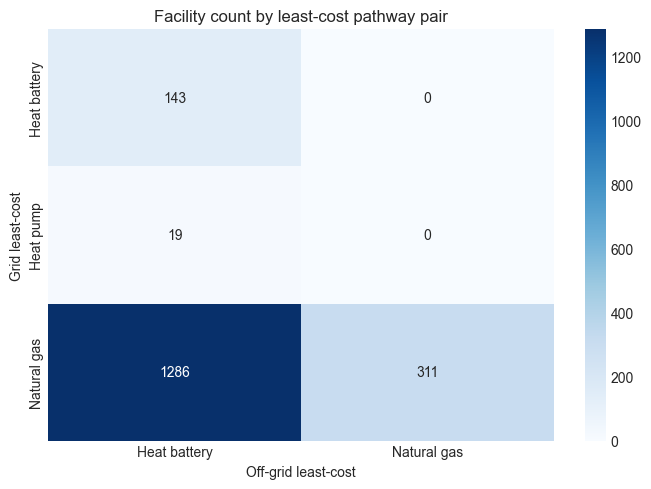

Pathway transitions (grid → off):
pathway_flip
natural_gas → heat_battery    1286
same                           454
heat_pump → heat_battery        19


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_ct = pd.crosstab(m["least_cost_pathway_grid"], m["least_cost_pathway_off"])
sns.heatmap(
    plot_ct,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=[PATHWAY_LABELS.get(c, c) for c in plot_ct.columns],
    yticklabels=[PATHWAY_LABELS.get(c, c) for c in plot_ct.index],
)
ax.set_xlabel("Off-grid least-cost")
ax.set_ylabel("Grid least-cost")
ax.set_title("Facility count by least-cost pathway pair")
plt.tight_layout()
plt.show()

print("Pathway transitions (grid → off):")
print(m["pathway_flip"].value_counts().to_string())


## 2. Matching vs diverging sites


In [24]:
match = m[m["same_pathway"]].copy()
diverge = m[~m["same_pathway"]].copy()

pd.DataFrame({
    "Category": ["Same least-cost pathway", "Different least-cost pathway", "Total compared"],
    "Facilities": [len(match), len(diverge), len(m)],
    "Share (%)": [100 * len(match) / len(m), 100 * len(diverge) / len(m), 100.0],
})


,Category,Facilities,Share (%)
0,Same least-cost pathway,454,25.810119
1,Different least-cost pathway,1305,74.189881
2,Total compared,1759,100.000000


In [25]:
diverge.groupby("pathway_flip").agg(
    n=("eprtr_facility_id", "count"),
    heat_TWh=("heat_MWh", lambda s: s.sum() / 1e6),
    mean_delta_winner=("delta_winner_lcoh", "mean"),
    median_delta_winner=("delta_winner_lcoh", "median"),
).sort_values("n", ascending=False)


,n,heat_TWh,mean_delta_winner,median_delta_winner
pathway_flip,,,,
natural_gas → heat_battery,1286,1849.661984,-39.855490,-44.674
heat_pump → heat_battery,19,10.041366,-42.012632,-38.904


In [26]:
EXPORT_COLS = [
    "eprtr_facility_id", "facility_name", "country", "iso3", "analysis_year", "temp_band",
    "heat_MWh",
    "least_cost_pathway_grid", "least_cost_pathway_off", "pathway_flip",
    "lcoh_winner_grid", "lcoh_winner_off", "delta_winner_lcoh",
    "lcoh_gas_grid", "lcoh_gas_off", "lcoh_hb_grid", "lcoh_hb_off",
    "lcoh_hp_grid", "lcoh_hp_off",
    "elec_grid_EUR_MWh", "elec_off_hb_EUR_MWh", "elec_off_hp_EUR_MWh", "gas_EUR_MWh",
]

OUT_DIR.mkdir(parents=True, exist_ok=True)
match.sort_values("heat_MWh", ascending=False)[EXPORT_COLS].to_csv(
    OUT_DIR / "cross_run_matching_pathway.csv", index=False
)
diverge.sort_values("delta_winner_lcoh")[EXPORT_COLS].to_csv(
    OUT_DIR / "cross_run_diverging_pathway.csv", index=False
)
print(f"Wrote {len(match):,} matching and {len(diverge):,} diverging rows to {OUT_DIR}/")


Wrote 454 matching and 1,305 diverging rows to /Users/annayuen/Desktop/IECC/industrial_decarb/LCOH_EU_workflow/outputs/


## 3. LCOH differences by technology

**Gas** LCOH should be ~0 delta (same Eurostat gas + ETS). **HB** and **HP** deltas reflect grid tariff vs BNEF off-grid electricity.


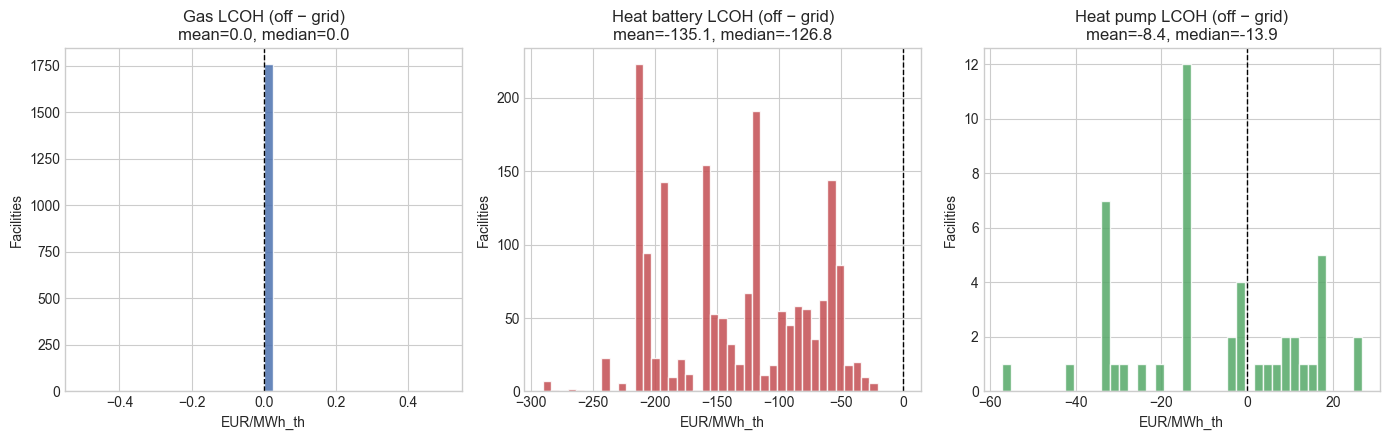

count    1759.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: delta_lcoh_gas, dtype: float64

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
panels = [
    ("delta_lcoh_gas", "Gas LCOH (off − grid)", "#4C72B0"),
    ("delta_lcoh_hb", "Heat battery LCOH (off − grid)", "#C44E52"),
    ("delta_lcoh_hp", "Heat pump LCOH (off − grid)", "#55A868"),
]
for ax, (col, title, color) in zip(axes, panels):
    sub = m[col].dropna()
    ax.hist(sub, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_xlabel("EUR/MWh_th")
    ax.set_ylabel("Facilities")
    ax.set_title(f"{title}\nmean={sub.mean():.1f}, median={sub.median():.1f}")
plt.tight_layout()
plt.show()
m["delta_lcoh_gas"].describe()


## 4. Electricity price context


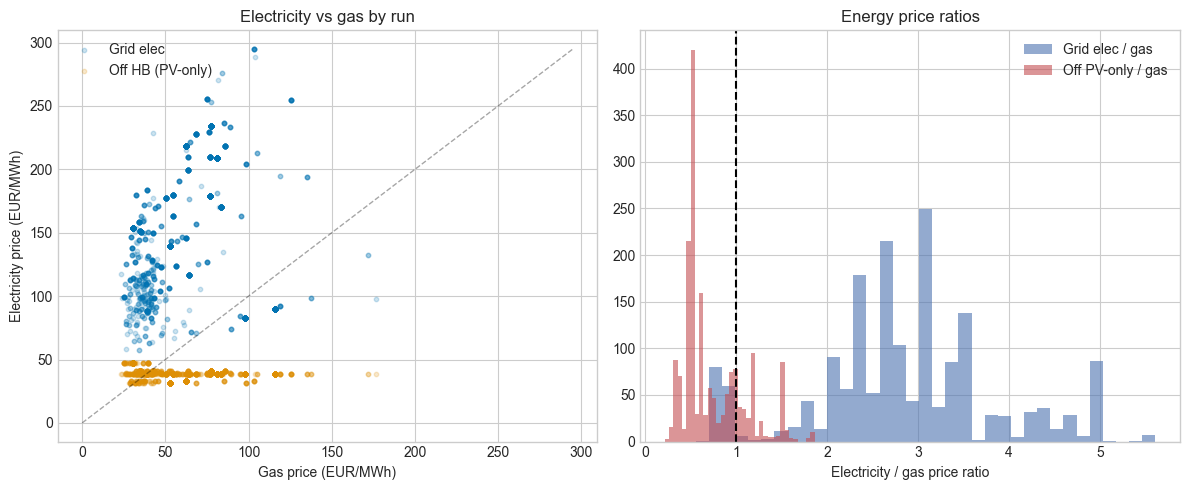

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(m["gas_EUR_MWh"], m["elec_grid_EUR_MWh"], alpha=0.2, s=10, label="Grid elec")
axes[0].scatter(m["gas_EUR_MWh"], m["elec_off_hb_EUR_MWh"], alpha=0.2, s=10, label="Off HB (PV-only)")
lim = max(m["elec_grid_EUR_MWh"].max(), m["elec_off_hb_EUR_MWh"].max())
axes[0].plot([0, lim], [0, lim], "k--", lw=1, alpha=0.35)
axes[0].set_xlabel("Gas price (EUR/MWh)")
axes[0].set_ylabel("Electricity price (EUR/MWh)")
axes[0].set_title("Electricity vs gas by run")
axes[0].legend()

m["ratio_grid_gas"] = m["elec_grid_EUR_MWh"] / m["gas_EUR_MWh"]
m["ratio_offhb_gas"] = m["elec_off_hb_EUR_MWh"] / m["gas_EUR_MWh"]
axes[1].hist(m["ratio_grid_gas"], bins=35, alpha=0.6, label="Grid elec / gas", color="#4C72B0")
axes[1].hist(m["ratio_offhb_gas"], bins=35, alpha=0.6, label="Off PV-only / gas", color="#C44E52")
axes[1].axvline(1, color="k", ls="--")
axes[1].set_xlabel("Electricity / gas price ratio")
axes[1].set_title("Energy price ratios")
axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Country-level view


In [ ]:
by_country = (
    m.groupby("iso3")
    .agg(
        n=("eprtr_facility_id", "count"),
        pct_same=("same_pathway", lambda s: 100 * s.mean()),
        pct_off_hb=("least_cost_pathway_off", lambda s: 100 * (s == "heat_battery").mean()),
        pct_grid_gas=("least_cost_pathway_grid", lambda s: 100 * (s == "natural_gas").mean()),
        mean_delta_hb=("delta_lcoh_hb", "mean"),
        mean_elec_grid=("elec_grid_EUR_MWh", "mean"),
        mean_elec_off_hb=("elec_off_hb_EUR_MWh", "mean"),
    )
    .sort_values("n", ascending=False)
)
by_country.head(20)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
top = by_country.head(15)
x = np.arange(len(top))
ax.bar(x - 0.2, top["pct_same"], 0.4, label="% same pathway", color="#8172B3")
ax.bar(x + 0.2, top["pct_off_hb"], 0.4, label="% off-grid HB wins", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(top.index)
ax.set_ylabel("% of facilities")
ax.set_title("Top 15 countries by facility count")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Diverging sites — largest winner LCOH swings


In [ ]:
diverge.sort_values("delta_winner_lcoh", key=abs, ascending=False)[EXPORT_COLS].head(20)


In [ ]:
gas_to_hb = diverge[
    (diverge["least_cost_pathway_grid"] == "natural_gas")
    & (diverge["least_cost_pathway_off"] == "heat_battery")
]
hb_to_gas = diverge[
    (diverge["least_cost_pathway_grid"] == "heat_battery")
    & (diverge["least_cost_pathway_off"] == "natural_gas")
]

print(f"natural_gas → heat_battery: {len(gas_to_hb):,}")
print(f"  Mean grid gas LCOH:     {gas_to_hb['lcoh_gas_grid'].mean():.1f} EUR/MWh_th")
print(f"  Mean off HB LCOH:       {gas_to_hb['lcoh_hb_off'].mean():.1f} EUR/MWh_th")
print(f"  Mean HB LCOH drop:      {(gas_to_hb['lcoh_hb_grid'] - gas_to_hb['lcoh_hb_off']).mean():.1f} (grid−off elec scenario)")

print(f"\nheat_battery → natural_gas: {len(hb_to_gas):,}")
if len(hb_to_gas):
    print(f"  Mean grid HB LCOH:      {hb_to_gas['lcoh_hb_grid'].mean():.1f}")
    print(f"  Mean off gas LCOH:      {hb_to_gas['lcoh_gas_off'].mean():.1f}")


## 7. Same pathway — breakdown


In [ ]:
match.groupby(["least_cost_pathway_grid", "least_cost_pathway_off"]).agg(
    n=("eprtr_facility_id", "count"),
    mean_winner_lcoh_grid=("lcoh_winner_grid", "mean"),
    mean_winner_lcoh_off=("lcoh_winner_off", "mean"),
).reset_index()


## 8. Optional: pathway-level cross-run flags


In [ ]:
if CROSS_PATH.exists():
    xrun = pd.read_csv(CROSS_PATH)
    print(f"{CROSS_PATH.name}: {len(xrun):,} rows")
    display(xrun.head())
else:
    print("No cross_run_comparison.csv — facility merge above is the primary comparison.")


## 9. Key takeaways

Among **1,759** computed facilities present in both runs:

| | Facilities | Share |
|---|--:|--:|
| **Same** least-cost pathway | 454 | 25.8% |
| **Different** least-cost pathway | 1,305 | 74.2% |

**Dominant flip:** grid **natural gas** → off-grid **heat battery** (**1,286** sites). The reverse (HB → gas on off-grid) is **311** sites where BNEF PV is less competitive than grid HB economics suggested.

**Matching sites (454):** mostly **gas wins both** (311) or **heat battery wins both** (143); all **19** grid heat-pump winners flip to off-grid HB (HP not least-cost off-grid in this run).

**Mechanism:** gas LCOH is unchanged between runs; ranking shifts come from **electricity** (Eurostat industrial tariff vs BNEF PV / PV+BESS), not gas.

**Exports:** `outputs/cross_run_matching_pathway.csv` and `outputs/cross_run_diverging_pathway.csv`.
